# FMCG Sales Analytics - Python Workflow





In [ ]:
import pandas as pd

## Data Loading


In [ ]:
df = pd.read_csv("/content/FMCG_Analytics_View.csv")

In [ ]:
df.head()

,proper_date,Year,Year_Month,sku,brand,category,channel,region,promotion_flag,units_sold,price_unit,Revenue
0,21-01-2022,2022,2022-01,MI-006,MiBrand1,Milk,Retail,PL-Central,0,9,2.38,21.42
1,21-01-2022,2022,2022-01,MI-006,MiBrand1,Milk,Retail,PL-North,1,0,1.55,0.00
2,21-01-2022,2022,2022-01,MI-006,MiBrand1,Milk,Retail,PL-South,0,8,4.00,32.00
3,21-01-2022,2022,2022-01,MI-006,MiBrand1,Milk,Discount,PL-Central,0,7,5.16,36.12
4,21-01-2022,2022,2022-01,MI-006,MiBrand1,Milk,Discount,PL-North,0,12,7.66,91.92


In [ ]:
df.shape

(190757, 12)

In [ ]:
df.columns = df.columns.str.lower().str.strip()

df.columns

Index(['proper_date', 'year', 'year_month', 'sku', 'brand', 'category',
       'channel', 'region', 'promotion_flag', 'units_sold', 'price_unit',
       'revenue'],
      dtype='object')

In [ ]:
df.info

<bound method DataFrame.info of        proper_date  year year_month     sku     brand  category     channel  \
0       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk      Retail   
1       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk      Retail   
2       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk      Retail   
3       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk    Discount   
4       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk    Discount   
...            ...   ...        ...     ...       ...       ...         ...   
190752  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar    Discount   
190753  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar    Discount   
190754  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar  E-commerce   
190755  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar  E-commerce   
190756  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar  E-commerce   

            region  promotion_flag  units_sold  price_unit  revenue  
0       PL-Central               0           9        2.38    21.42  
1         PL-North               1           0        1.55     0.00  
2         PL-South               0           8        4.00    32.00  
3       PL-Central               0           7        5.16    36.12  
4         PL-North               0          12        7.66    91.92  
...            ...             ...         ...         ...      ...  
190752    PL-North               0          25        2.55    63.75  
190753    PL-South               0          19        6.01   114.19  
190754  PL-Central               0           0        3.45     0.00  
190755    PL-North               1          40        1.93    77.20  
190756    PL-South               0           8        1.91    15.28  

[190757 rows x 12 columns]>

In [ ]:
df.describe

<bound method NDFrame.describe of        proper_date  year year_month     sku     brand  category     channel  \
0       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk      Retail   
1       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk      Retail   
2       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk      Retail   
3       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk    Discount   
4       21-01-2022  2022    2022-01  MI-006  MiBrand1      Milk    Discount   
...            ...   ...        ...     ...       ...       ...         ...   
190752  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar    Discount   
190753  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar    Discount   
190754  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar  E-commerce   
190755  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar  E-commerce   
190756  31-12-2024  2024    2024-12  SN-030  SnBrand2  SnackBar  E-commerce   

            region  promotion_flag  units_sold  price_unit  revenue  
0       PL-Central               0           9        2.38    21.42  
1         PL-North               1           0        1.55     0.00  
2         PL-South               0           8        4.00    32.00  
3       PL-Central               0           7        5.16    36.12  
4         PL-North               0          12        7.66    91.92  
...            ...             ...         ...         ...      ...  
190752    PL-North               0          25        2.55    63.75  
190753    PL-South               0          19        6.01   114.19  
190754  PL-Central               0           0        3.45     0.00  
190755    PL-North               1          40        1.93    77.20  
190756    PL-South               0           8        1.91    15.28  

[190757 rows x 12 columns]>

# Data Cleaning


In [ ]:
df['proper_date'] = pd.to_datetime(df['proper_date'])

df['proper_date'].dtype

/tmp/ipython-input-788747541.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['proper_date'] = pd.to_datetime(df['proper_date'])


dtype('<M8[ns]')

In [ ]:
df.groupby('year')['revenue'].sum()

,revenue
year,
2022,3166961.51
2023,8436253.56
2024,8348085.51


# Revenue by Year



In [ ]:
yearly_revenue = df.groupby('year')['revenue'].sum().sort_index()

yoy_growth = yearly_revenue.pct_change() * 100

pd.DataFrame({
    'Revenue': yearly_revenue,
    'YoY_Growth_%': yoy_growth
})

,Revenue,YoY_Growth_%
year,,
2022,3166961.51,NaN
2023,8436253.56,166.383205
2024,8348085.51,-1.045109


## Monthly Revenue Trend Analysis

In [ ]:
monthly_revenue = df.groupby('year_month')['revenue'].sum().sort_index()

monthly_revenue.head(36)

,revenue
year_month,
2022-01,10719.36
2022-02,29181.55
2022-03,86890.92
2022-04,178015.88
2022-05,273859.61
2022-06,332079.35
2022-07,379645.34
2022-08,367004.50
2022-09,341473.15


# **Yearly Revenue Trend Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

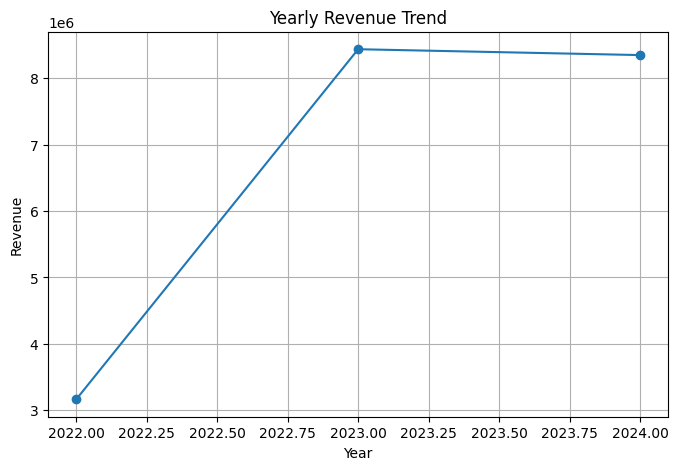

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(yearly_revenue.index, yearly_revenue.values, marker='o')

plt.title("Yearly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.grid(True)
plt.show()

# **Monthly Revenue Trend**

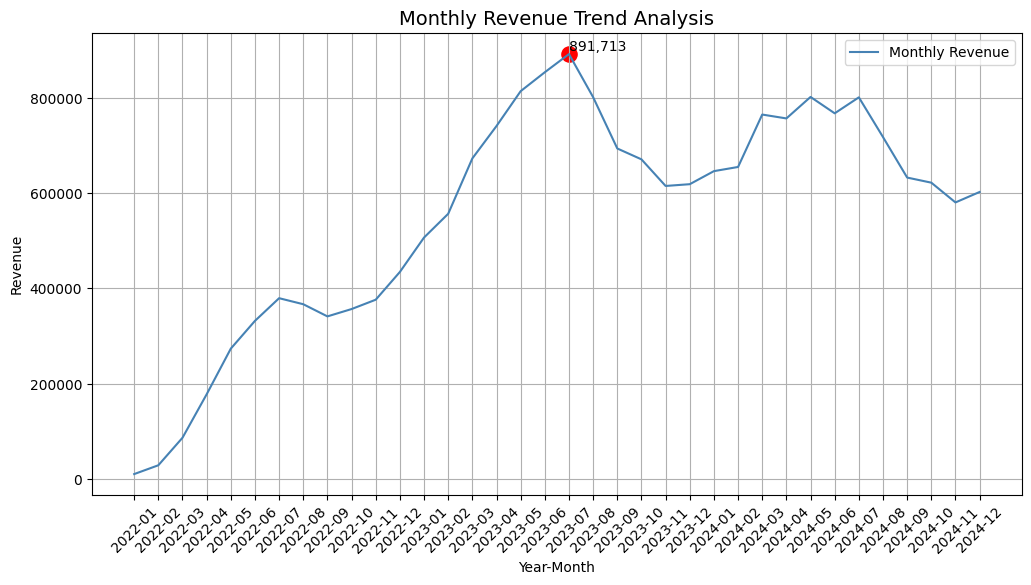

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot main line
plt.plot(monthly_revenue.index.astype(str),
         monthly_revenue.values,
         color='steelblue',
         label='Monthly Revenue')

# Get highest value
max_value = monthly_revenue.max()
max_index = monthly_revenue.idxmax()

# Highlight highest point
plt.scatter(str(max_index),
            max_value,
            color='red',
            s=120)

# Add integer label
plt.text(str(max_index),
         max_value,
         f"{int(max_value):,}",
         color='black',
         fontsize=10,
         ha='left',
         va='bottom')

plt.title("Monthly Revenue Trend Analysis", fontsize=14)
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

# **Revenue Contribution by channel**

In [ ]:
channel_revenue = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

channel_revenue

,revenue
channel,
Retail,6655592.06
E-commerce,6653435.41
Discount,6642273.11


In [ ]:
channel_percent = (channel_revenue / channel_revenue.sum()) * 100

channel_analysis = pd.DataFrame({
    'Revenue': channel_revenue,
    'Contribution_%': channel_percent
})

channel_analysis

,Revenue,Contribution_%
channel,,
Retail,6655592.06,33.359189
E-commerce,6653435.41,33.348379
Discount,6642273.11,33.292432


In [ ]:
channel_analysis.columns = channel_analysis.columns.str.lower()
channel_analysis

,revenue,contribution_%
channel,,
Retail,6655592.06,33.359189
E-commerce,6653435.41,33.348379
Discount,6642273.11,33.292432


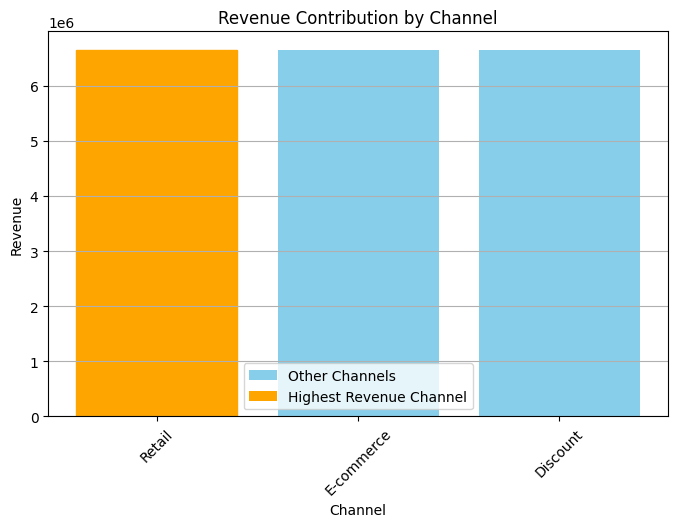

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(channel_analysis.index,
               channel_analysis['revenue'],
               color='skyblue',
               label='Channel Revenue')

# Identify highest revenue channel
max_index = channel_analysis['revenue'].idxmax()
max_position = list(channel_analysis.index).index(max_index)

# Highlight highest bar
bars[max_position].set_color('orange')

# Add manual legend entry for highlight
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='skyblue', label='Other Channels'),
    Patch(facecolor='orange', label='Highest Revenue Channel')
]

plt.legend(handles=legend_elements)

plt.title("Revenue Contribution by Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

# **Channel Revenue Year**

In [ ]:
channel_yearly = df.groupby(['year','channel'])['revenue'].sum().unstack()

channel_yearly

channel,Discount,E-commerce,Retail
year,,,
2022,1062638.92,1042182.88,1062139.71
2023,2807765.40,2818210.92,2810277.24
2024,2771868.79,2793041.61,2783175.11


In [ ]:
channel_yoy = channel_yearly.pct_change() * 100

channel_yoy

channel,Discount,E-commerce,Retail
year,,,
2022,NaN,NaN,NaN
2023,164.225726,170.414241,164.586402
2024,-1.278476,-0.893095,-0.964393


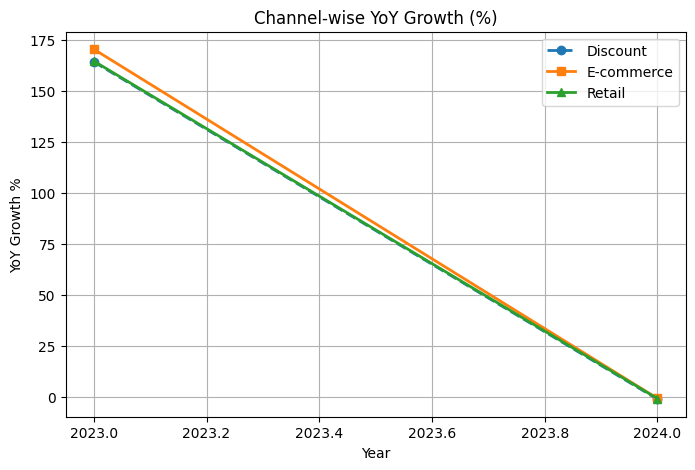

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(channel_yoy.index,
         channel_yoy['Discount'],
         marker='o',
         linestyle='--',
         linewidth=2,
         label='Discount')

plt.plot(channel_yoy.index,
         channel_yoy['E-commerce'],
         marker='s',
         linewidth=2,
         label='E-commerce')

plt.plot(channel_yoy.index,
         channel_yoy['Retail'],
         marker='^',
         linewidth=2,
         label='Retail')

plt.title("Channel-wise YoY Growth (%)")
plt.xlabel("Year")
plt.ylabel("YoY Growth %")

plt.legend()
plt.grid(True)
plt.show()

# **Revenue by Promotional flag**

In [ ]:
promotion_revenue = df.groupby('promotion_flag')['revenue'].sum()

promotion_revenue

,revenue
promotion_flag,
0,14849830.28
1,5101470.30


In [ ]:
promotion_percent = (promotion_revenue / promotion_revenue.sum()) * 100

promotion_analysis = pd.DataFrame({
    'Revenue': promotion_revenue,
    'Contribution_%': promotion_percent
})

promotion_analysis

,Revenue,Contribution_%
promotion_flag,,
0,14849830.28,74.430387
1,5101470.30,25.569613


# **Promotion impact on units sold**

In [ ]:
df.groupby('promotion_flag')['units_sold'].mean()

,units_sold
promotion_flag,
0,17.439900
1,34.060574


In [ ]:
no_promo = df.groupby('promotion_flag')['units_sold'].mean()[0]
promo = df.groupby('promotion_flag')['units_sold'].mean()[1]

uplift_percent = ((promo - no_promo) / no_promo) * 100

uplift_percent

np.float64(95.3025776760221)

# **Promotion uplift visualization**

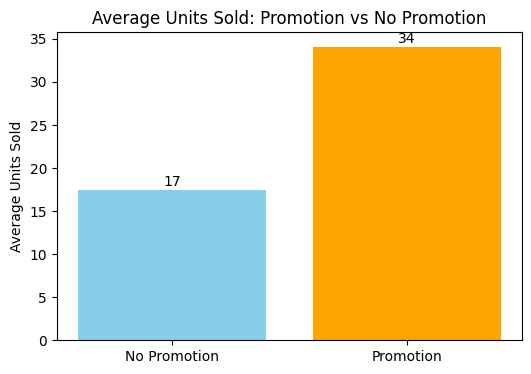

In [ ]:
avg_units = df.groupby('promotion_flag')['units_sold'].mean()

plt.figure(figsize=(6,4))

bars = plt.bar(['No Promotion','Promotion'],
               avg_units,
               color=['skyblue','orange'])

plt.title("Average Units Sold: Promotion vs No Promotion")
plt.ylabel("Average Units Sold")

# Add integer labels
for i, value in enumerate(avg_units):
    plt.text(i, value + 0.5, f"{int(value)}", ha='center')

plt.show()

# **Regional Revenue Analysis**

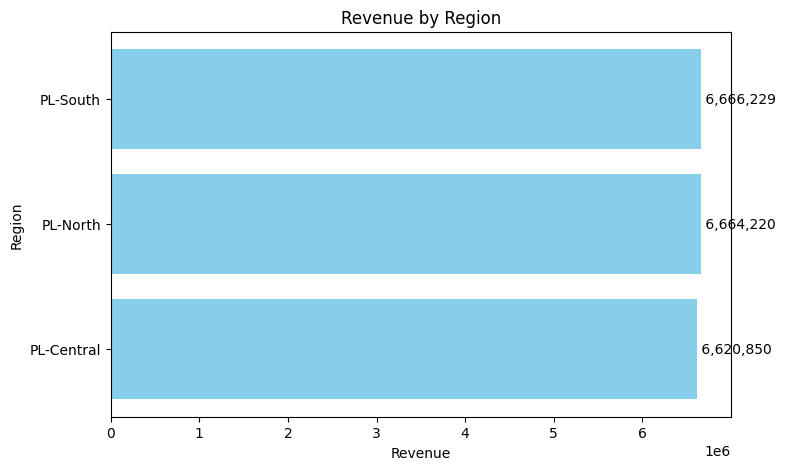

In [ ]:
import matplotlib.pyplot as plt

region_revenue = df.groupby('region')['revenue'].sum().sort_values()

plt.figure(figsize=(8,5))

bars = plt.barh(region_revenue.index,
                region_revenue.values,
                color='skyblue')

plt.title("Revenue by Region")
plt.xlabel("Revenue")
plt.ylabel("Region")

# Add revenue labels
for i, value in enumerate(region_revenue.values):
    plt.text(value, i, f" {int(value):,}", va='center')

plt.grid(False)
plt.show()

# **Revenue Analysis by category**

In [ ]:
category_revenue = df.groupby('category')['revenue'].sum().sort_values()

category_revenue

,revenue
category,
Juice,652277.27
SnackBar,3401125.56
ReadyMeal,3576329.02
Milk,4095375.42
Yogurt,8226193.31


In [ ]:
category_revenue_m = (df.groupby('category')['revenue']
                      .sum()
                      .sort_values() / 1_000_000)

category_revenue_m

,revenue
category,
Juice,0.652277
SnackBar,3.401126
ReadyMeal,3.576329
Milk,4.095375
Yogurt,8.226193


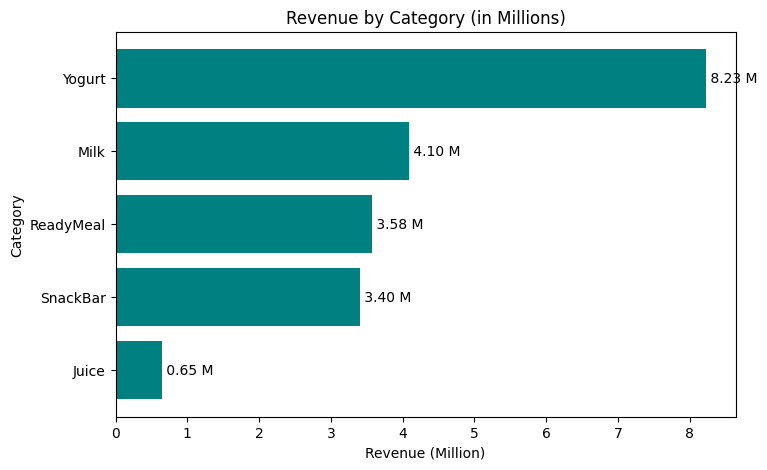

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.barh(category_revenue_m.index,
                category_revenue_m.values,
                color='teal')

plt.title("Revenue by Category (in Millions)")
plt.xlabel("Revenue (Million)")
plt.ylabel("Category")

# Add labels with 2 decimal places
for i, value in enumerate(category_revenue_m.values):
    plt.text(value, i, f" {value:.2f} M", va='center')

plt.grid(False)
plt.show()

## Category-wise Year-over-Year **Growth**

In [ ]:
category_yearly = df.groupby(['year','category'])['revenue'].sum().unstack()

category_yearly

category,Juice,Milk,ReadyMeal,SnackBar,Yogurt
year,,,,,
2022,142123.45,760217.20,640350.45,107251.12,1517019.29
2023,271127.98,1674337.60,1509342.07,1656255.21,3325190.70
2024,239025.84,1660820.62,1426636.50,1637619.23,3383983.32


In [ ]:
category_yoy = category_yearly.pct_change() * 100

category_yoy

category,Juice,Milk,ReadyMeal,SnackBar,Yogurt
year,,,,,
2022,NaN,NaN,NaN,NaN,NaN
2023,90.769349,120.244635,135.705631,1444.277775,119.192381
2024,-11.840217,-0.807303,-5.479578,-1.125188,1.768098


## Monthly Revenue Forecasting (ARIMA Model)

In [ ]:
monthly_revenue = df.groupby('proper_date')['revenue'].sum().resample('M').sum()

monthly_revenue.head()

/tmp/ipython-input-4016401946.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.groupby('proper_date')['revenue'].sum().resample('M').sum()


,revenue
proper_date,
2022-01-31,10719.36
2022-02-28,29181.55
2022-03-31,86890.92
2022-04-30,178015.88
2022-05-31,273859.61


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(monthly_revenue, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -427.592
Date:                Wed, 25 Feb 2026   AIC                            861.183
Time:                        12:46:24   BIC                            865.850
Sample:                    01-31-2022   HQIC                           862.794
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6946      0.271      2.564      0.010       0.164       1.226
ma.L1         -0.2019      0.328     -0.615      0.538      -0.845       0.441
sigma2      2.457e+09   3.91e-11   6.28e+19      0.0

In [ ]:
# Forecast next 6 months
forecast = model_fit.forecast(steps=6)

forecast

,predicted_mean
2025-01-31,608525.364652
2025-02-28,612735.507143
2025-03-31,615659.728741
2025-04-30,617690.793480
2025-05-31,619101.501880
2025-06-30,620081.331893


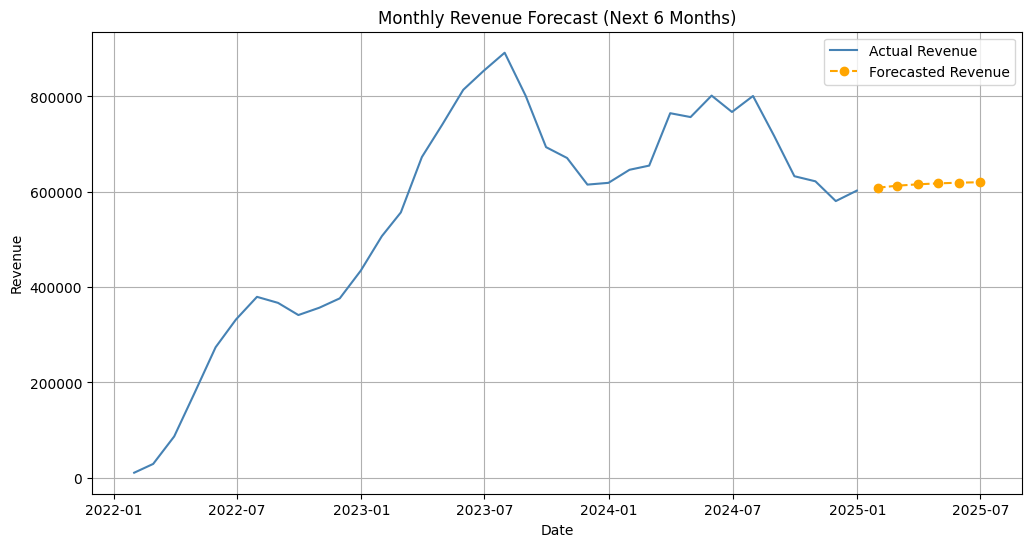

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot actual data
plt.plot(monthly_revenue.index,
         monthly_revenue.values,
         label='Actual Revenue',
         color='steelblue')

# Plot forecast
plt.plot(forecast.index,
         forecast.values,
         label='Forecasted Revenue',
         color='orange',
         linestyle='--',
         marker='o')

plt.title("Monthly Revenue Forecast (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.legend()
plt.grid(True)

plt.show()

# Key Business Insights & Strategic Recommendations
**Revenue Performance**

Revenue grew sharply in 2023 (~166% YoY), indicating strong structural expansion.

2024 shows stabilization (~ -1% YoY), suggesting market maturity phase.

Growth was company-wide, not limited to a single channel.

**Channel Insights**

* Revenue distribution is balanced across Retail, E-commerce, and Discount (~33% each)
* E-commerce showed slightly stronger growth in 2023.
* No over-dependence on a single channel → Strong omnichannel structure.

**Promotion Effectiveness**

* Promotions contribute ~26% of total revenue.
* However, promotions increase average units sold by ~95%.
* Indicates strong volume uplift but business is not promotion-dependent.

**Regional Insights**

* Revenue distribution across regions is relatively balanced.  
* No single region dominates, reducing geographic risk exposure.

 Category Insights

*  Yogurt is the highest revenue-generating category.
*  Yogurt remains resilient even in 2024 stabilization phase.
*  Portfolio is diversified, but Yogurt is strategic growth driver.

**Forecasting Insights**

* ARIMA forecast suggests stable to moderate revenue growth.
* No sharp decline expected in next 6 months.
* Business entering steady-state maturity.

**Strategic Recommendations**

*  Continue investing in Yogurt category.
*  Optimize promotion strategy to maximize volume without over-discounting.
*  Strengthen E-commerce growth momentum.
*  Focus on maintaining balanced regional expansion.
*  Monitor stabilization trend closely in 2025.






In [ ]:
df.to_csv("fmcg_clean_final.csv", index=False)

In [ ]:
from google.colab import files
files.download("fmcg_clean_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>